# 02 - Dimensionality reduction and clustering

HVG selection, scaling, PCA, UMAP and Leiden clustering.

The scaled matrix is built on a **copy** that is thrown away; the object written to disk keeps
`X` as sparse log1p(CP10K) and only gains `obsm["X_pca"]`, `obsm["X_umap"]` and `obs["leiden"]`.
That matters for two reasons: the file stays ~150 MB instead of 1.1 GB, and scDRS (notebook 06)
needs normalised - not z-scaled - expression.

Output: `interim/adata_clustered.h5ad`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from adpipe import *

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
adata = sc.read_h5ad(INTERIM / "adata_lognorm.h5ad")
print(adata.n_obs, "nuclei x", adata.n_vars, "genes")

13214 nuclei x 10850 genes


In [2]:
N_HVG, N_PCS, N_NEIGHBORS, RESOLUTION = 3000, 30, 15, 0.5

sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG)
print("highly variable genes:", int(adata.var["highly_variable"].sum()))

# Scaling happens on a throwaway copy restricted to the HVGs
emb = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(emb, max_value=10)
print("embedding matrix:", emb.shape)

highly variable genes: 3000


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


embedding matrix: (13214, 3000)


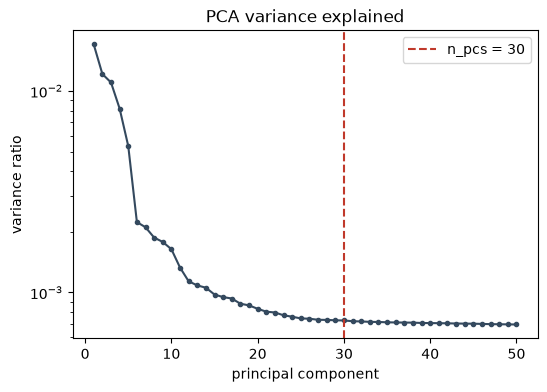

In [3]:
sc.tl.pca(emb, svd_solver="arpack", n_comps=50)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, 51), emb.uns["pca"]["variance_ratio"], "o-", ms=3, color="#34495e")
ax.axvline(N_PCS, color="#c0392b", ls="--", label=f"n_pcs = {N_PCS}")
ax.set(xlabel="principal component", ylabel="variance ratio", yscale="log")
ax.legend()
ax.set_title("PCA variance explained")
plt.show()

In [4]:
sc.pp.neighbors(emb, n_neighbors=N_NEIGHBORS, n_pcs=N_PCS, transformer="sklearn")
sc.tl.umap(emb)
sc.tl.leiden(emb, resolution=RESOLUTION, flavor="igraph", n_iterations=2, directed=False)
print("Leiden clusters:", emb.obs["leiden"].nunique())

C:\Users\Admin\Desktop\azihmer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Leiden clusters: 17


In [5]:
# Carry the embedding back onto the normalised object and drop the scaled copy
adata.obsm["X_pca"] = emb.obsm["X_pca"]
adata.obsm["X_umap"] = emb.obsm["X_umap"]
adata.obs["leiden"] = emb.obs["leiden"].values
adata.uns["pca"] = emb.uns["pca"]
adata.uns["pipeline"] = {"n_hvg": N_HVG, "n_pcs": N_PCS,
                         "n_neighbors": N_NEIGHBORS, "leiden_resolution": RESOLUTION}
del emb

adata.write(INTERIM / "adata_clustered.h5ad")
size = (INTERIM / "adata_clustered.h5ad").stat().st_size / 1e6
print(f"interim -> interim/adata_clustered.h5ad ({size:.0f} MB, X still sparse log1p)")

interim -> interim/adata_clustered.h5ad (153 MB, X still sparse log1p)


  figure -> results/figures/02_umap_overview.png  (642 KB)


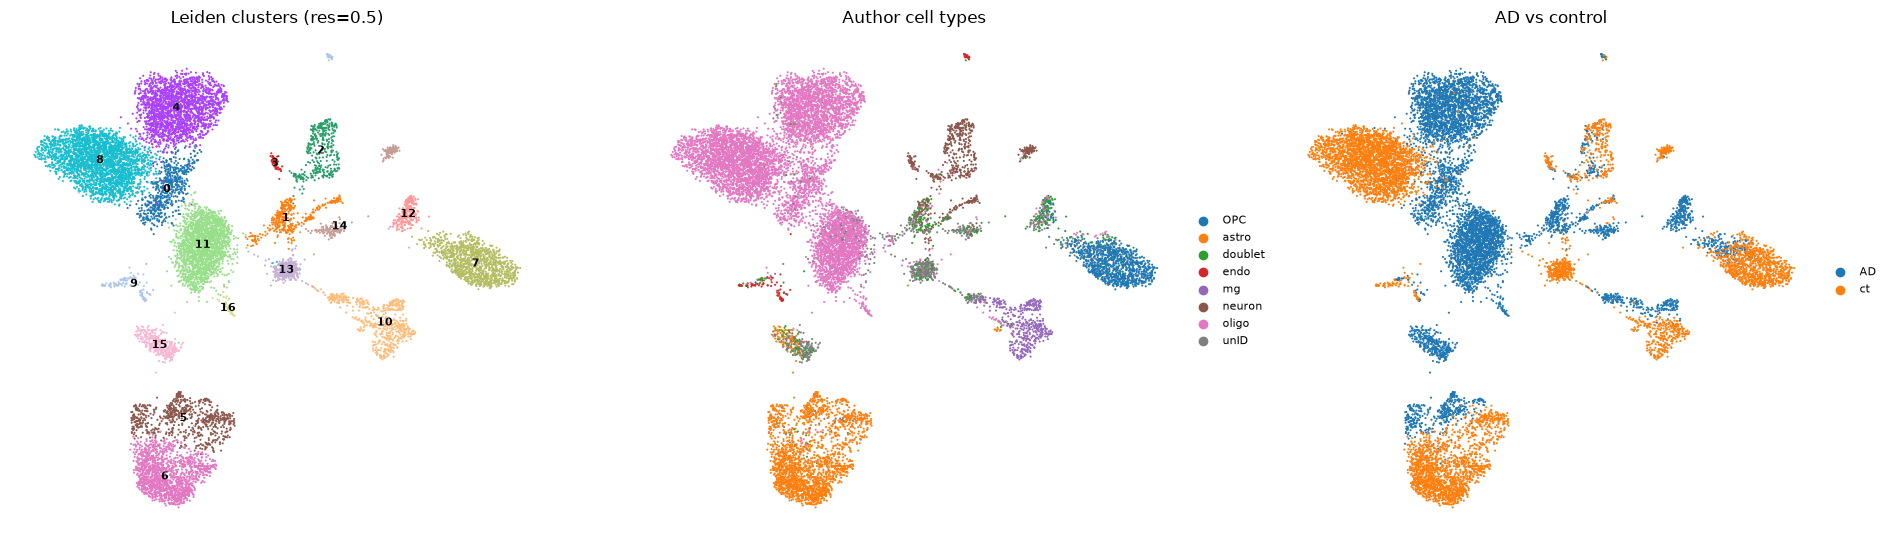

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, colour, title in zip(
    axes,
    ["leiden", "oupSample.cellType", "oupSample.batchCond"],
    [f"Leiden clusters (res={RESOLUTION})", "Author cell types", "AD vs control"],
):
    sc.pl.umap(adata, color=colour, ax=ax, show=False, frameon=False, title=title,
               legend_loc="on data" if colour == "leiden" else "right margin",
               legend_fontsize=8)
plt.tight_layout()
save_fig(fig, "02_umap_overview")
plt.show()

In [7]:
composition = pd.crosstab(adata.obs["leiden"], adata.obs["oupSample.cellType"])
composition["dominant_cellType"] = composition.idxmax(axis=1)
composition["n_AD"] = pd.crosstab(adata.obs["leiden"], adata.obs["oupSample.batchCond"])["AD"]
composition["n_ct"] = pd.crosstab(adata.obs["leiden"], adata.obs["oupSample.batchCond"])["ct"]
save_table(composition, "02_cluster_composition")
composition

  table -> results/tables/02_cluster_composition.tsv  (17 rows x 11 cols, 1 KB)


oupSample.cellType,OPC,astro,doublet,endo,mg,neuron,oligo,unID,dominant_cellType,n_AD,n_ct
leiden,,,,,,,,,,,
0,0,0,0,1,0,0,589,3,oligo,578,15
1,0,0,91,0,0,159,26,94,neuron,332,38
2,0,1,4,0,0,346,5,0,neuron,104,252
3,0,0,0,0,0,54,1,0,neuron,11,44
4,0,0,3,0,0,0,2039,13,oligo,2041,14
5,0,647,6,0,0,0,5,23,astro,384,297
6,0,1415,9,0,0,0,8,3,astro,8,1427
7,1047,1,36,0,0,0,14,47,OPC,180,965
8,0,0,0,0,0,0,2718,5,oligo,66,2657
